# Full Model Troubleshooting Notebook

This is the main debugging notebook for the real code in `src/`. It uses the current config API, trains both stages, and focuses on graph-heavy troubleshooting for Task 8 Stage 1 and the initial Task 9 single-model Stage 2 path.

## Imports and Project Path

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

root = Path.cwd()
while root != root.parent and not (root / 'src').exists():
    root = root.parent
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))

from config import Stage1ModelConfig, Stage2ModelConfig, StageTrainingConfig, TwoStageRunConfig, TwoStageStackConfig
from datasets import build_two_stage_datasets
from models import (
    Stage1Regressor,
    Stage2ConvDecoder,
    Stage2MaskPredictor,
    binary_iou,
    evaluate_regression_predictions,
    evaluate_stage2_predictions,
    fit_stage1_model,
    fit_stage2_model,
    predict_stage1_coefficients,
    predict_stage2_logits,
    set_torch_seed,
)
np.random.seed(42)
set_torch_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Debug Run Config

These defaults are moderate enough for troubleshooting but still large enough to show real failure modes. The notebook now keeps one shared Stage 1 path, then compares two Stage 2 variants directly: an MLP with edge weighting and a conv decoder with edge weighting.

In [ ]:
run_config = TwoStageRunConfig(
    N=10,
    training_samples=10000,
    validation_samples=2000,
    test_samples=2000,
    grid_size=32,
    noise_level=0.01,
    threshold=0.5,
    seed=42,
    model=TwoStageStackConfig(
        stage1=Stage1ModelConfig(
            hidden_layer_sizes=(128, 256, 128),
            dropout_rates=(0.2, 0.2, 0.2),
            training=StageTrainingConfig(
                epochs=200,
                batch_size=32,
                learning_rate=0.0005,
                validation_frequency=10,
                verbose=True,
                early_stopping_patience=10,
            ),
        ),
        stage2=Stage2ModelConfig(
            hidden_layer_sizes=(512, 1024, 2048),
            dropout_rates=(0.2, 0.2, 0.2),
            training=StageTrainingConfig(
                epochs=150,
                batch_size=64,
                learning_rate=0.001,
                validation_frequency=30,
                verbose=True,
                early_stopping_patience=20,
                min_epochs=40,
                min_improvement=0.005,
                lr_drop_factor=0.5,
                lr_drop_period=50,
                weight_decay=0.0001,
                gradient_clip_norm=1.0,
            ),
        ),
    ),
    output_dir=Path('outputs/test'),
)
run_config

TwoStageRunConfig(N=15, training_samples=10000, validation_samples=2000, test_samples=2000, rho=0.8, grid_size=32, threshold=0.5, use_validation_threshold_sweep=False, threshold_candidates=(0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7), noise_level=0.01, seed=42, training_shape_weights=None, model=TwoStageStackConfig(stage1=Stage1ModelConfig(hidden_layer_sizes=(128, 256, 128), dropout_rates=(0.2, 0.2, 0.2), training=StageTrainingConfig(epochs=200, batch_size=32, learning_rate=0.0005, validation_frequency=10, verbose=True, early_stopping_patience=10, min_epochs=None, min_improvement=None, lr_drop_factor=None, lr_drop_period=None, weight_decay=0.0, gradient_clip_norm=None, loss_type='bce', dice_loss_weight=0.0, dice_smooth=1.0)), stage2=Stage2ModelConfig(hidden_layer_sizes=(512, 1024, 2048), dropout_rates=(0.2, 0.2, 0.2), model_type='mlp', latent_grid_size=8, latent_channels=64, decoder_channels=(64, 32, 16), use_rectangle_edge_weighting=False, rectangle_edge_weight=3.0, rectangle_edg

In [3]:
print('N:', run_config.N)
print('Train / validation / test:', run_config.training_samples, run_config.validation_samples, run_config.test_samples)
print('Grid size:', run_config.grid_size)
print('Noise level:', run_config.noise_level)
print('Threshold:', run_config.threshold)
print('Gradient feature size:', run_config.gradient_feature_size)
print('Coefficient feature size:', run_config.coefficient_size)
print('Mask pixels:', run_config.mask_pixels)
print('Stage 1 layers:', run_config.model.stage1.hidden_layer_sizes)
print('Stage 2 layers:', run_config.model.stage2.hidden_layer_sizes)
print('Stage 2 dropout:', run_config.model.stage2.dropout_rates)

N: 15
Train / validation / test: 10000 2000 2000
Grid size: 32
Noise level: 0.01
Threshold: 0.5
Gradient feature size: 32
Coefficient feature size: 32
Mask pixels: 1024
Stage 1 layers: (128, 256, 128)
Stage 2 layers: (512, 1024, 2048)
Stage 2 dropout: (0.2, 0.2, 0.2)


## Build Dataset

In [4]:
dataset = build_two_stage_datasets(run_config)
print('Condition number:', dataset.matrix_condition_number)
print('Train gradient data shape:', dataset.train.gradient_data.shape)
print('Train coefficients shape:', dataset.train.coefficients.shape)
print('Train masks shape:', dataset.train.masks.shape)
print('Fixed benchmark examples:', len(dataset.fixed.names))

Condition number: 1.0000000000000009
Train gradient data shape: (10000, 32)
Train coefficients shape: (10000, 32)
Train masks shape: (10000, 1024)
Fixed benchmark examples: 5


## Notebook Helper Functions

These helpers keep the notebook focused on diagnosis rather than raw plotting boilerplate.

In [5]:
def sigmoid(logits):
    return 1.0 / (1.0 + np.exp(-logits))

def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())

def compute_sample_ious(y_true, logits, threshold):
    probabilities = sigmoid(logits)
    binary_predictions = (probabilities >= threshold).astype(np.float32)
    return np.array([binary_iou(true_row, pred_row) for true_row, pred_row in zip(y_true, binary_predictions, strict=False)])

def compute_sample_pixel_accuracy(y_true, logits, threshold):
    probabilities = sigmoid(logits)
    binary_predictions = (probabilities >= threshold).astype(np.float32)
    return np.mean(binary_predictions == y_true, axis=1)

def plot_history(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(np.arange(1, len(history['train_loss']) + 1), history['train_loss'], marker='o')
    axes[0].set_title(f'{title_prefix} Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['validation_steps'], history['val_loss'], marker='o', color='tab:orange')
    axes[1].set_title(f'{title_prefix} Validation Loss')
    axes[1].set_xlabel('Validation step')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

def plot_shape_type_breakdown(shape_types, values, title, ylabel):
    frame = pd.DataFrame({'shape_type': shape_types, 'value': values})
    summary = frame.groupby('shape_type', sort=True)['value'].mean().sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    summary.plot(kind='bar')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel('Shape type')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()
    return summary

def plot_threshold_sweep(y_true, logits, thresholds):
    rows = []
    for threshold in thresholds:
        metrics = evaluate_stage2_predictions(y_true, logits, threshold)
        rows.append({
            'threshold': threshold,
            'mean_iou': metrics['mean_iou'],
            'pixel_accuracy': metrics['pixel_accuracy'],
        })
    frame = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(frame['threshold'], frame['mean_iou'], marker='o')
    axes[0].set_title('Threshold vs Mean IoU')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Mean IoU')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(frame['threshold'], frame['pixel_accuracy'], marker='o', color='tab:orange')
    axes[1].set_title('Threshold vs Pixel Accuracy')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Pixel Accuracy')
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()
    return frame

def show_reconstruction_rows(true_masks, logits, names, grid_size, threshold, row_indices, title):
    probabilities = sigmoid(logits)
    binary_predictions = (probabilities >= threshold).astype(np.float32)
    fig, axes = plt.subplots(len(row_indices), 4, figsize=(12, 3 * len(row_indices)))
    if len(row_indices) == 1:
        axes = np.array([axes])
    for plot_row, sample_index in enumerate(row_indices):
        true_mask = true_masks[sample_index].reshape(grid_size, grid_size)
        probability_mask = probabilities[sample_index].reshape(grid_size, grid_size)
        predicted_mask = binary_predictions[sample_index].reshape(grid_size, grid_size)
        false_positive = ((predicted_mask == 1) & (true_mask == 0)).astype(np.float32)
        false_negative = ((predicted_mask == 0) & (true_mask == 1)).astype(np.float32)

        axes[plot_row, 0].imshow(true_mask, cmap='gray', origin='lower')
        axes[plot_row, 0].set_title(f'True: {names[sample_index]}')
        axes[plot_row, 0].axis('off')

        axes[plot_row, 1].imshow(probability_mask, cmap='viridis', origin='lower', vmin=0.0, vmax=1.0)
        axes[plot_row, 1].set_title('Predicted probability')
        axes[plot_row, 1].axis('off')

        axes[plot_row, 2].imshow(predicted_mask, cmap='gray', origin='lower')
        axes[plot_row, 2].set_title('Thresholded prediction')
        axes[plot_row, 2].axis('off')

        error_overlay = false_positive - false_negative
        axes[plot_row, 3].imshow(error_overlay, cmap='bwr', origin='lower', vmin=-1.0, vmax=1.0)
        axes[plot_row, 3].set_title('Error overlay')
        axes[plot_row, 3].axis('off')

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

def show_simple_mask_pairs(true_masks, predicted_masks, names, grid_size, row_indices, title, score_values=None, score_label='IoU'):
    fig, axes = plt.subplots(len(row_indices), 2, figsize=(6, 3 * len(row_indices)))
    if len(row_indices) == 1:
        axes = np.array([axes])
    for plot_row, sample_index in enumerate(row_indices):
        axes[plot_row, 0].imshow(true_masks[sample_index].reshape(grid_size, grid_size), cmap='gray', origin='lower')
        axes[plot_row, 0].set_title(f'True: {names[sample_index]}')
        axes[plot_row, 0].axis('off')

        axes[plot_row, 1].imshow(predicted_masks[sample_index].reshape(grid_size, grid_size), cmap='gray', origin='lower')
        if score_values is None:
            axes[plot_row, 1].set_title('Predicted')
        else:
            axes[plot_row, 1].set_title(f'Predicted\n{score_label}={score_values[sample_index]:.3f}')
        axes[plot_row, 1].axis('off')

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

def show_average_maps_by_shape_type(shape_types, true_masks, logits, grid_size, threshold):
    probabilities = sigmoid(logits)
    binary_predictions = (probabilities >= threshold).astype(np.float32)
    unique_shape_types = sorted(set(shape_types))
    fig, axes = plt.subplots(len(unique_shape_types), 3, figsize=(9, 3 * len(unique_shape_types)))
    if len(unique_shape_types) == 1:
        axes = np.array([axes])
    for row_index, shape_type in enumerate(unique_shape_types):
        type_indices = [index for index, current_type in enumerate(shape_types) if current_type == shape_type]
        mean_true = true_masks[type_indices].mean(axis=0).reshape(grid_size, grid_size)
        mean_probability = probabilities[type_indices].mean(axis=0).reshape(grid_size, grid_size)
        mean_error = np.abs(binary_predictions[type_indices] - true_masks[type_indices]).mean(axis=0).reshape(grid_size, grid_size)

        axes[row_index, 0].imshow(mean_true, cmap='gray', origin='lower')
        axes[row_index, 0].set_title(f'{shape_type}: mean true mask')
        axes[row_index, 0].axis('off')

        axes[row_index, 1].imshow(mean_probability, cmap='viridis', origin='lower', vmin=0.0, vmax=1.0)
        axes[row_index, 1].set_title('Mean predicted probability')
        axes[row_index, 1].axis('off')

        axes[row_index, 2].imshow(mean_error, cmap='magma', origin='lower', vmin=0.0, vmax=1.0)
        axes[row_index, 2].set_title('Mean absolute mask error')
        axes[row_index, 2].axis('off')

    fig.tight_layout()
    plt.show()

## Stage 1 Setup and Training

In [6]:
stage1_model = Stage1Regressor(
    input_dim=run_config.gradient_feature_size,
    output_dim=run_config.coefficient_size,
    hidden_dims=run_config.model.stage1.hidden_layer_sizes,
    dropout_rates=run_config.model.stage1.dropout_rates,
)
print(stage1_model)
print('Stage 1 parameter count:', count_parameters(stage1_model))
stage1_result = fit_stage1_model(
    model=stage1_model,
    train_features=dataset.train.gradient_data,
    train_targets=dataset.train.coefficients,
    val_features=dataset.validation.gradient_data,
    val_targets=dataset.validation.coefficients,
    epochs=run_config.model.stage1.training.epochs,
    batch_size=run_config.model.stage1.training.batch_size,
    learning_rate=run_config.model.stage1.training.learning_rate,
    device=device,
    validation_frequency=run_config.model.stage1.training.validation_frequency,
    verbose=run_config.model.stage1.training.verbose,
    early_stopping_patience=run_config.model.stage1.training.early_stopping_patience,
)

Stage1Regressor(
  (network): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=32, bias=True)
  )
)
Stage 1 parameter count: 74272
Epoch 1/200 | step 10 | train_loss=1.439599 | val_loss=0.886999
Epoch 1/200 | step 20 | train_loss=1.289811 | val_loss=0.867197
Epoch 1/200 | step 30 | train_loss=1.050825 | val_loss=0.847141
Epoch 1/200 | step 40 | train_loss=1.005235 | val_loss=0.827267
Epoch 1/200 | step 50 | train_loss=0.965569 | val_loss=0.801092
Epoch 1/200 | step 60 | train_loss=0.942622 | val_loss=0.771340
Epoch 1/200 | step 70 | train_loss=0.910024 | val_loss=0.738927
Epoch 1/200 | step 80 | train_loss=0.920954 | val_loss=0.70567

## Stage 1 Diagnostics

Stage 1 test metrics: {'mse': 1.3003578715142794e-05, 'mae': 0.0011830396251752973}
Stage 1 fixed metrics: {'mse': 6.314060556178447e-06, 'mae': 0.0007145024137571454}
Stage 1 stored X_mu shape: (32,)
Stage 1 stored Y_mu shape: (32,)


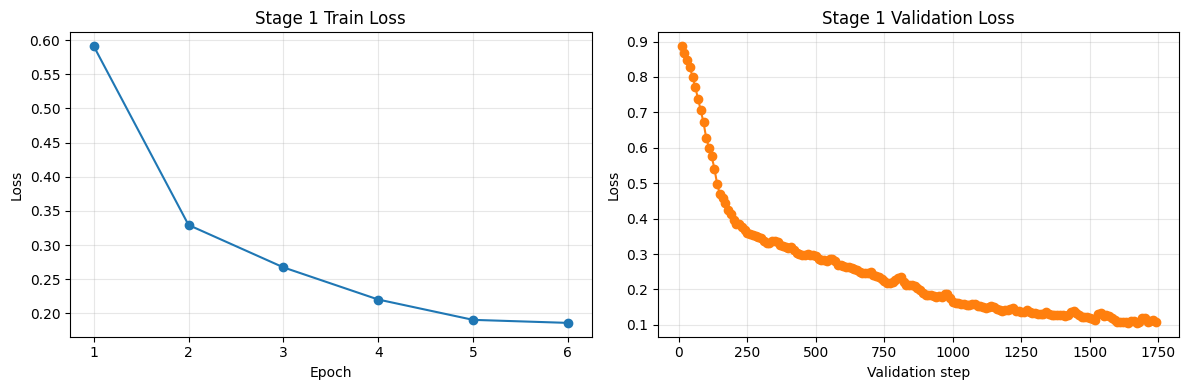

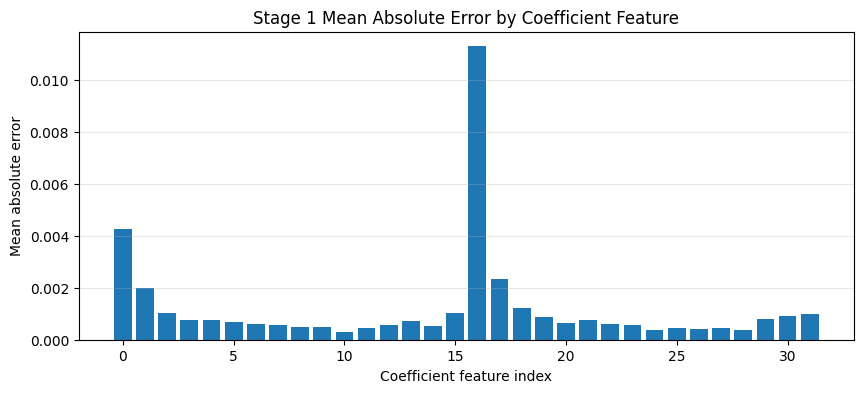

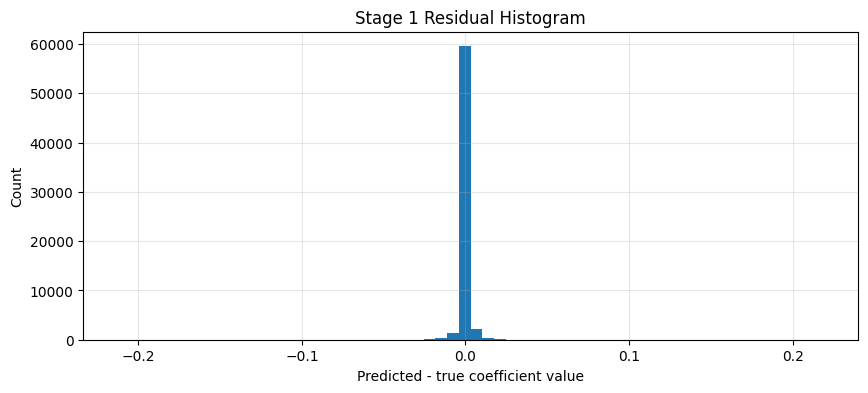

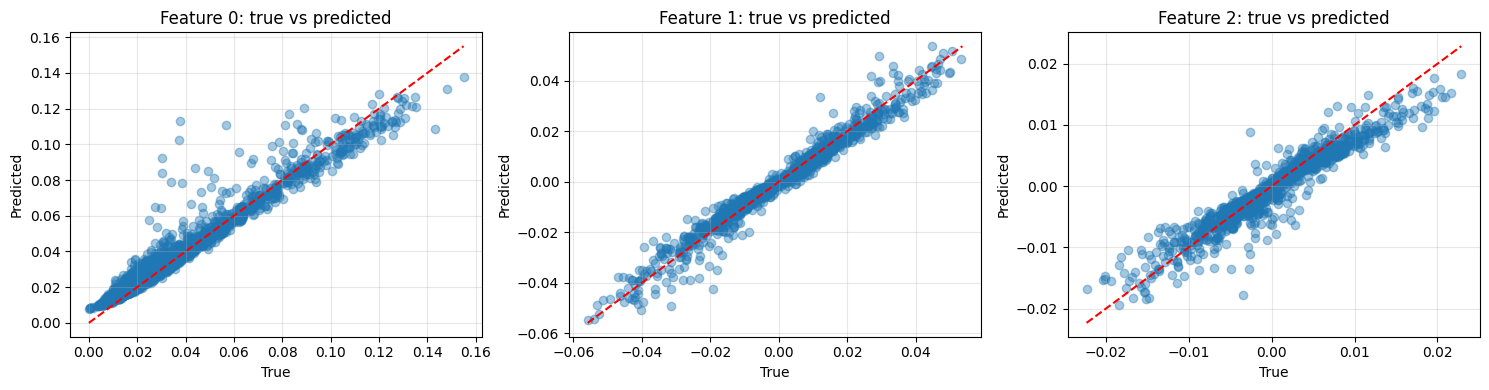

In [7]:
predicted_train_coefficients = predict_stage1_coefficients(stage1_model, dataset.train.gradient_data, device=device, training_result=stage1_result)
predicted_validation_coefficients = predict_stage1_coefficients(stage1_model, dataset.validation.gradient_data, device=device, training_result=stage1_result)
predicted_test_coefficients = predict_stage1_coefficients(stage1_model, dataset.test.gradient_data, device=device, training_result=stage1_result)
predicted_fixed_coefficients = predict_stage1_coefficients(stage1_model, dataset.fixed.gradient_data, device=device, training_result=stage1_result)

stage1_test_metrics = evaluate_regression_predictions(dataset.test.coefficients, predicted_test_coefficients)
stage1_fixed_metrics = evaluate_regression_predictions(dataset.fixed.coefficients, predicted_fixed_coefficients)
print('Stage 1 test metrics:', stage1_test_metrics)
print('Stage 1 fixed metrics:', stage1_fixed_metrics)
print('Stage 1 stored X_mu shape:', stage1_result.input_mean.shape)
print('Stage 1 stored Y_mu shape:', stage1_result.target_mean.shape)
plot_history(stage1_result.history, 'Stage 1')

coefficient_errors = np.abs(predicted_validation_coefficients - dataset.validation.coefficients)
mean_coefficient_errors = coefficient_errors.mean(axis=0)
plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(mean_coefficient_errors)), mean_coefficient_errors)
plt.title('Stage 1 Mean Absolute Error by Coefficient Feature')
plt.xlabel('Coefficient feature index')
plt.ylabel('Mean absolute error')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.hist((predicted_validation_coefficients - dataset.validation.coefficients).reshape(-1), bins=60)
plt.title('Stage 1 Residual Histogram')
plt.xlabel('Predicted - true coefficient value')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, feature_index in zip(axes, (0, 1, 2), strict=False):
    true_values = dataset.validation.coefficients[:, feature_index]
    predicted_values = predicted_validation_coefficients[:, feature_index]
    lower_bound = min(true_values.min(), predicted_values.min())
    upper_bound = max(true_values.max(), predicted_values.max())
    axis.scatter(true_values, predicted_values, alpha=0.4)
    axis.plot([lower_bound, upper_bound], [lower_bound, upper_bound], linestyle='--', color='red')
    axis.set_title(f'Feature {feature_index}: true vs predicted')
    axis.set_xlabel('True')
    axis.set_ylabel('Predicted')
    axis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Stage 2 Setup and Training

In [8]:
stage2_variants = {
    'mlp_edges_rectangle': Stage2ModelConfig(
        hidden_layer_sizes=run_config.model.stage2.hidden_layer_sizes,
        dropout_rates=run_config.model.stage2.dropout_rates,
        model_type='mlp',
        use_rectangle_edge_weighting=True,
        rectangle_edge_weight=3.0,
        rectangle_edge_width=2,
        edge_weight_mode='rectangle',
        training=run_config.model.stage2.training,
    ),
    'decoder_edges_rectangle': Stage2ModelConfig(
        hidden_layer_sizes=(256, 512, 512),
        dropout_rates=(0.15, 0.15),
        model_type='conv_decoder',
        latent_grid_size=8,
        latent_channels=96,
        decoder_channels=(96, 64, 32),
        use_rectangle_edge_weighting=True,
        rectangle_edge_weight=3.0,
        rectangle_edge_width=2,
        edge_weight_mode='all',
        training=StageTrainingConfig(
            epochs=run_config.model.stage2.training.epochs,
            batch_size=128,
            learning_rate=0.0007,
            validation_frequency=60,
            verbose=run_config.model.stage2.training.verbose,
            early_stopping_patience=run_config.model.stage2.training.early_stopping_patience,
            min_epochs=run_config.model.stage2.training.min_epochs,
            min_improvement=run_config.model.stage2.training.min_improvement,
            lr_drop_factor=run_config.model.stage2.training.lr_drop_factor,
            lr_drop_period=60,
            weight_decay=0.0002,
            gradient_clip_norm=0.8,
            loss_type='bce',
            dice_loss_weight=0.0,
            dice_smooth=1.0,
        ),
    ),
}

def build_stage2_model_from_config(stage2_config):
    if stage2_config.model_type == 'mlp':
        return Stage2MaskPredictor(
            input_dim=run_config.coefficient_size,
            output_dim=run_config.mask_pixels,
            hidden_dims=stage2_config.hidden_layer_sizes,
            dropout_rates=stage2_config.dropout_rates,
        )
    if stage2_config.model_type == 'conv_decoder':
        return Stage2ConvDecoder(
            input_dim=run_config.coefficient_size,
            output_dim=run_config.mask_pixels,
            hidden_dims=stage2_config.hidden_layer_sizes,
            dropout_rates=stage2_config.dropout_rates,
            latent_grid_size=stage2_config.latent_grid_size,
            latent_channels=stage2_config.latent_channels,
            decoder_channels=stage2_config.decoder_channels,
        )
    raise ValueError(f'Unsupported stage2 model_type: {stage2_config.model_type}')

def run_stage2_variant(label, stage2_config):
    model = build_stage2_model_from_config(stage2_config)
    print(label)
    print(model)
    print('Stage 2 parameter count:', count_parameters(model))
    result = fit_stage2_model(
        model=model,
        train_features=predicted_train_coefficients,
        train_targets=dataset.train.masks,
        val_features=predicted_validation_coefficients,
        val_targets=dataset.validation.masks,
        epochs=stage2_config.training.epochs,
        batch_size=stage2_config.training.batch_size,
        learning_rate=stage2_config.training.learning_rate,
        device=device,
        validation_frequency=stage2_config.training.validation_frequency,
        verbose=stage2_config.training.verbose,
        early_stopping_patience=stage2_config.training.early_stopping_patience,
        train_shape_types=dataset.train.shape_types,
        grid_size=run_config.grid_size,
        use_rectangle_edge_weighting=stage2_config.use_rectangle_edge_weighting,
        rectangle_edge_weight=stage2_config.rectangle_edge_weight,
        rectangle_edge_width=stage2_config.rectangle_edge_width,
        edge_weight_mode=stage2_config.edge_weight_mode,
        min_epochs=stage2_config.training.min_epochs,
        min_improvement=stage2_config.training.min_improvement,
        lr_drop_factor=stage2_config.training.lr_drop_factor,
        lr_drop_period=stage2_config.training.lr_drop_period,
        weight_decay=stage2_config.training.weight_decay,
        gradient_clip_norm=stage2_config.training.gradient_clip_norm,
        loss_type=stage2_config.training.loss_type,
        dice_loss_weight=stage2_config.training.dice_loss_weight,
        dice_smooth=stage2_config.training.dice_smooth,
    )
    predicted_validation_logits = predict_stage2_logits(model, predicted_validation_coefficients, device=device, training_result=result)
    predicted_test_logits = predict_stage2_logits(model, predicted_test_coefficients, device=device, training_result=result)
    predicted_fixed_logits = predict_stage2_logits(model, predicted_fixed_coefficients, device=device, training_result=result)
    true_coefficient_fixed_logits = predict_stage2_logits(model, dataset.fixed.coefficients, device=device, training_result=result)
    validation_metrics = evaluate_stage2_predictions(dataset.validation.masks, predicted_validation_logits, run_config.threshold)
    test_metrics = evaluate_stage2_predictions(dataset.test.masks, predicted_test_logits, run_config.threshold)
    fixed_metrics = evaluate_stage2_predictions(dataset.fixed.masks, predicted_fixed_logits, run_config.threshold)
    true_coefficient_fixed_metrics = evaluate_stage2_predictions(dataset.fixed.masks, true_coefficient_fixed_logits, run_config.threshold)
    return {
        'label': label,
        'config': stage2_config,
        'model': model,
        'result': result,
        'predicted_validation_logits': predicted_validation_logits,
        'predicted_test_logits': predicted_test_logits,
        'predicted_fixed_logits': predicted_fixed_logits,
        'true_coefficient_fixed_logits': true_coefficient_fixed_logits,
        'validation_metrics': validation_metrics,
        'test_metrics': test_metrics,
        'fixed_metrics': fixed_metrics,
        'true_coefficient_fixed_metrics': true_coefficient_fixed_metrics,
        'validation_ious': compute_sample_ious(dataset.validation.masks, predicted_validation_logits, run_config.threshold),
        'validation_accuracy': compute_sample_pixel_accuracy(dataset.validation.masks, predicted_validation_logits, run_config.threshold),
    }

stage2_runs = {label: run_stage2_variant(label, config) for label, config in stage2_variants.items()}

mlp_edges_rectangle
Stage2MaskPredictor(
  (network): Sequential(
    (0): Linear(in_features=32, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=1024, out_features=2048, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=2048, out_features=1024, bias=True)
  )
)
Stage 2 parameter count: 4739584
Epoch 1/150 | step 30 | train_loss=0.933675 | val_loss=0.489751 | lr=0.001000
Epoch 1/150 | step 60 | train_loss=0.742606 | val_loss=0.410115 | lr=0.001000
Epoch 1/150 | step 90 | train_loss=0.659466 | val_loss=0.378464 | lr=0.001000
Epoch 1/150 | step 120 | train_loss=0.613817 | val_loss=0.366012 | lr=0.001000
Epoch 1/150 | step 150 | train_loss=0.580810 | val_loss=0.358002 | lr=0.001000
Epoch 2/150 | step 180 | train_loss=0.442251 | val_loss=0.339437 | lr=0.001000
Epoch 2

## Stage 2 Variant Comparison

mlp_edges_rectangle
Stage 2 validation metrics: {'mean_iou': 0.5613221825997765, 'pixel_accuracy': 0.932666003704071}
Stage 2 random test metrics: {'mean_iou': 0.5546178753839979, 'pixel_accuracy': 0.9320493340492249}
Stage 2 fixed benchmark metrics: {'mean_iou': 0.6409306168098351, 'pixel_accuracy': 0.917773425579071}
Stage 2 fixed metrics on true coefficients: {'mean_iou': 0.6175586859892535, 'pixel_accuracy': 0.908398449420929}


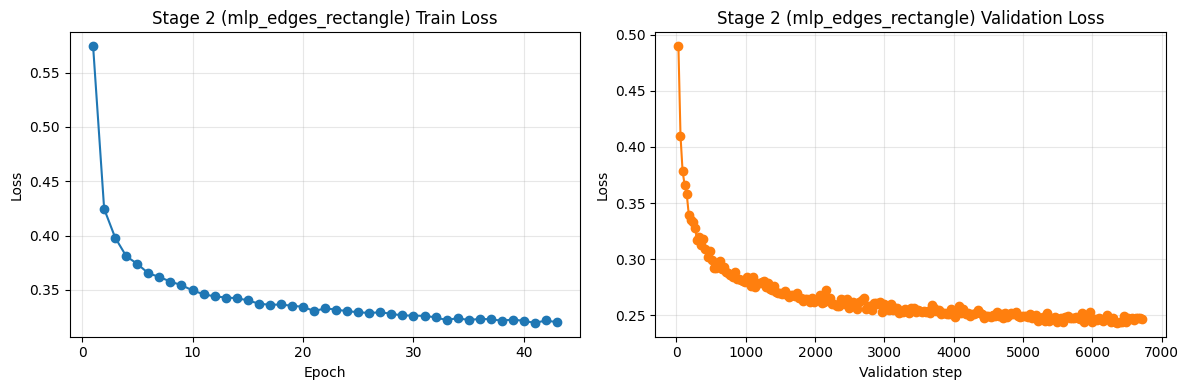

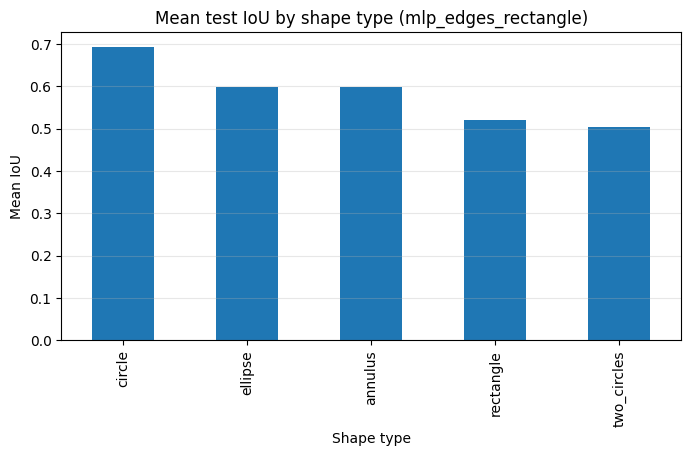

decoder_edges_rectangle
Stage 2 validation metrics: {'mean_iou': 0.6202968406501532, 'pixel_accuracy': 0.9467973709106445}
Stage 2 random test metrics: {'mean_iou': 0.6122602414898599, 'pixel_accuracy': 0.945672869682312}
Stage 2 fixed benchmark metrics: {'mean_iou': 0.7322148311642005, 'pixel_accuracy': 0.944140613079071}
Stage 2 fixed metrics on true coefficients: {'mean_iou': 0.6449056019742938, 'pixel_accuracy': 0.9251953363418579}


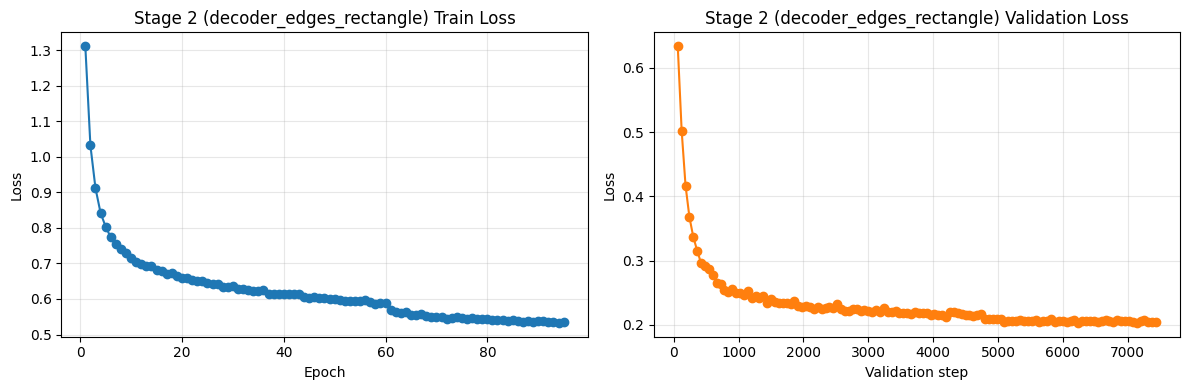

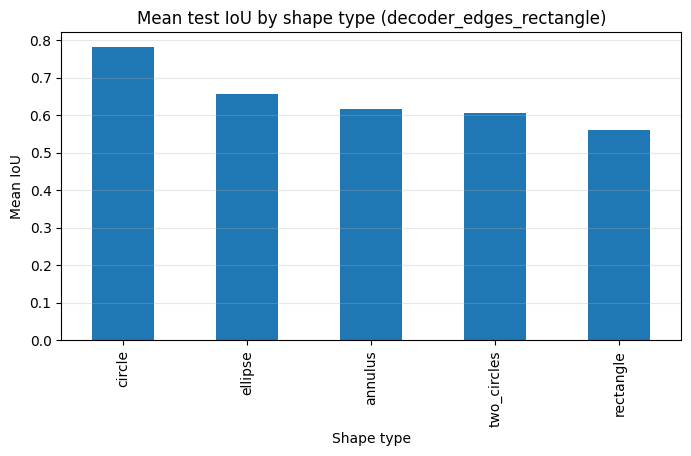

,label,model_type,edge_weight_mode,loss_type,stage2_validation_iou,stage2_test_iou,stage2_fixed_iou,stage2_fixed_iou_true_coeffs,stage2_parameters,stage2_train_epochs_recorded
0,decoder_edges_rectangle,conv_decoder,all,bce,0.620297,0.612260,0.732215,0.644906,3711841,95
1,mlp_edges_rectangle,mlp,rectangle,bce,0.561322,0.554618,0.640931,0.617559,4739584,43


In [9]:
stage2_comparison_rows = []
for label, run in stage2_runs.items():
    print(label)
    print('Stage 2 validation metrics:', run['validation_metrics'])
    print('Stage 2 random test metrics:', run['test_metrics'])
    print('Stage 2 fixed benchmark metrics:', run['fixed_metrics'])
    print('Stage 2 fixed metrics on true coefficients:', run['true_coefficient_fixed_metrics'])
    plot_history(run['result'].history, f'Stage 2 ({label})')
    plot_shape_type_breakdown(
        dataset.test.shape_types,
        compute_sample_ious(dataset.test.masks, run['predicted_test_logits'], run_config.threshold),
        f'Mean test IoU by shape type ({label})',
        'Mean IoU',
    )
    stage2_comparison_rows.append({
        'label': label,
        'model_type': run['config'].model_type,
        'edge_weight_mode': run['config'].edge_weight_mode,
        'loss_type': run['config'].training.loss_type,
        'stage2_validation_iou': run['validation_metrics']['mean_iou'],
        'stage2_test_iou': run['test_metrics']['mean_iou'],
        'stage2_fixed_iou': run['fixed_metrics']['mean_iou'],
        'stage2_fixed_iou_true_coeffs': run['true_coefficient_fixed_metrics']['mean_iou'],
        'stage2_parameters': count_parameters(run['model']),
        'stage2_train_epochs_recorded': len(run['result'].history['train_loss']),
    })

stage2_comparison_table = pd.DataFrame(stage2_comparison_rows).sort_values('stage2_validation_iou', ascending=False).reset_index(drop=True)
best_stage2_label = stage2_comparison_table.iloc[0]['label']
best_stage2_run = stage2_runs[best_stage2_label]
predicted_test_logits = best_stage2_run['predicted_test_logits']
predicted_fixed_logits = best_stage2_run['predicted_fixed_logits']
true_coefficient_fixed_logits = best_stage2_run['true_coefficient_fixed_logits']
test_metrics = best_stage2_run['test_metrics']
fixed_metrics = best_stage2_run['fixed_metrics']
true_coefficient_fixed_metrics = best_stage2_run['true_coefficient_fixed_metrics']
stage2_comparison_table

## Fixed Benchmark Reconstruction

This is the main benchmark view. It shows simple side-by-side actual vs predicted shapes first, then the richer comparisons between Stage 2 fed true coefficients and Stage 2 fed Stage 1 predicted coefficients.

In [10]:
fixed_stage1_coeff_errors = np.abs(predicted_fixed_coefficients - dataset.fixed.coefficients).mean(axis=1)
fixed_summary_table = pd.DataFrame({
    'shape_name': dataset.fixed.names,
    'shape_type': dataset.fixed.shape_types,
    'stage1_mean_abs_coeff_error': fixed_stage1_coeff_errors,
    'true_mask_area': dataset.fixed.masks.sum(axis=1),
})
for label, run in stage2_runs.items():
    fixed_ious = compute_sample_ious(dataset.fixed.masks, run['predicted_fixed_logits'], run_config.threshold)
    fixed_true_coeff_ious = compute_sample_ious(dataset.fixed.masks, run['true_coefficient_fixed_logits'], run_config.threshold)
    fixed_binary_masks = (sigmoid(run['predicted_fixed_logits']) >= run_config.threshold).astype(np.float32)
    fixed_summary_table[f'{label}_iou_true_coeffs'] = fixed_true_coeff_ious
    fixed_summary_table[f'{label}_iou_end_to_end'] = fixed_ious
    fixed_summary_table[f'{label}_iou_drop_from_stage1'] = fixed_true_coeff_ious - fixed_ious
    fixed_summary_table[f'{label}_predicted_mask_area'] = fixed_binary_masks.sum(axis=1)
fixed_summary_table

,shape_name,shape_type,stage1_mean_abs_coeff_error,true_mask_area,mlp_edges_rectangle_iou_true_coeffs,mlp_edges_rectangle_iou_end_to_end,mlp_edges_rectangle_iou_drop_from_stage1,mlp_edges_rectangle_predicted_mask_area,decoder_edges_rectangle_iou_true_coeffs,decoder_edges_rectangle_iou_end_to_end,decoder_edges_rectangle_iou_drop_from_stage1,decoder_edges_rectangle_predicted_mask_area
0,"Ellipse (a=0.6, b=0.3, theta=45)",ellipse,0.001001,137.0,0.665049,0.637209,0.027839,215.0,0.657609,0.750000,-0.092391,178.0
1,Circle (radius=0.5),circle,0.000686,187.0,0.660777,0.670251,-0.009474,279.0,0.806034,0.766393,0.039641,244.0
2,"Annulus (R=0.7, r=0.3)",annulus,0.000720,308.0,0.666667,0.721311,-0.054645,427.0,0.692135,0.747573,-0.055438,412.0
3,"Rectangle (0.8 x 0.4, theta=30)",rectangle,0.000290,76.0,0.514493,0.576923,-0.062430,129.0,0.468750,0.655172,-0.186422,116.0
4,Two Disconnected Circles,two_circles,0.000875,115.0,0.580808,0.598958,-0.018150,192.0,0.600000,0.741935,-0.141935,155.0


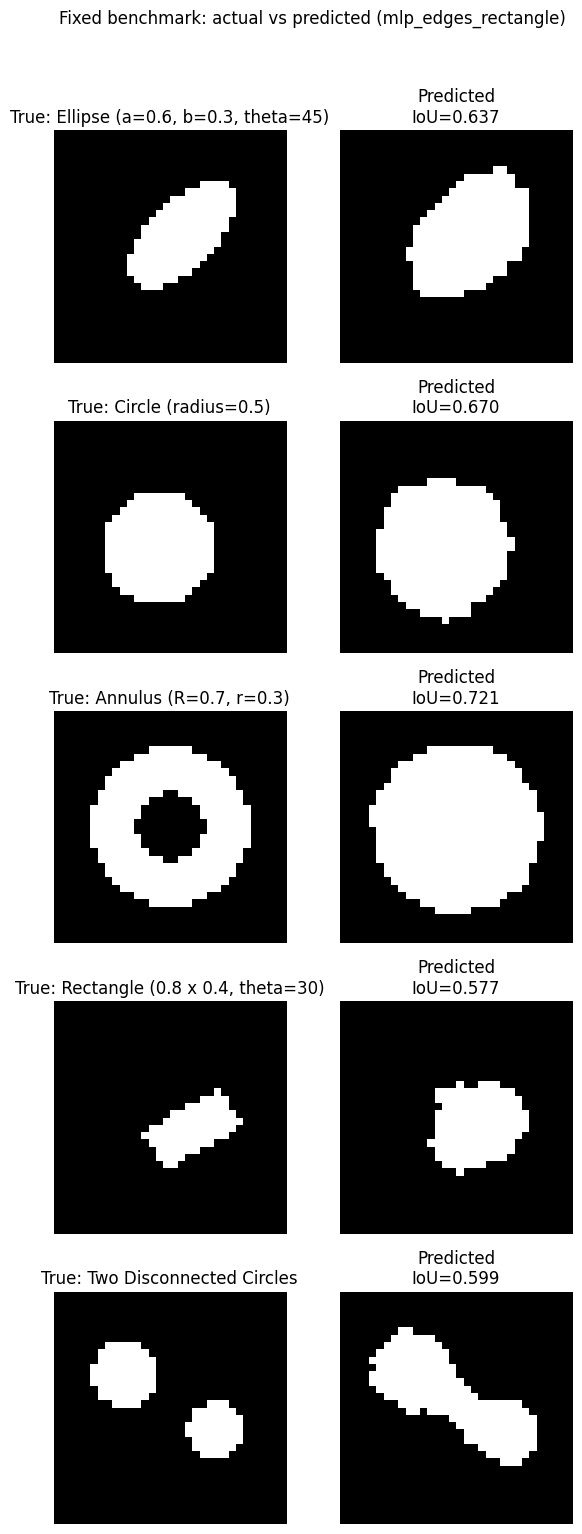

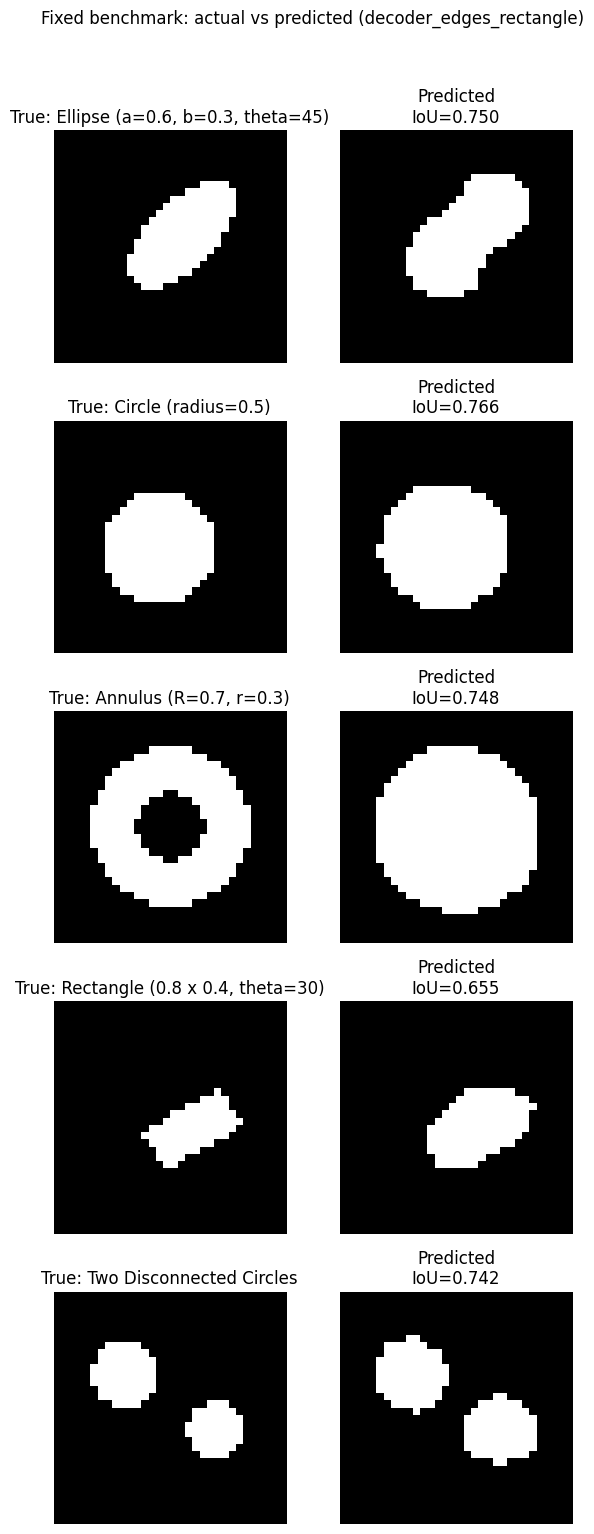

In [11]:
for label, run in stage2_runs.items():
    fixed_ious = compute_sample_ious(dataset.fixed.masks, run['predicted_fixed_logits'], run_config.threshold)
    fixed_binary_masks = (sigmoid(run['predicted_fixed_logits']) >= run_config.threshold).astype(np.float32)
    show_simple_mask_pairs(
        dataset.fixed.masks,
        fixed_binary_masks,
        dataset.fixed.names,
        run_config.grid_size,
        np.arange(len(dataset.fixed.names)),
        f'Fixed benchmark: actual vs predicted ({label})',
        score_values=fixed_ious,
    )

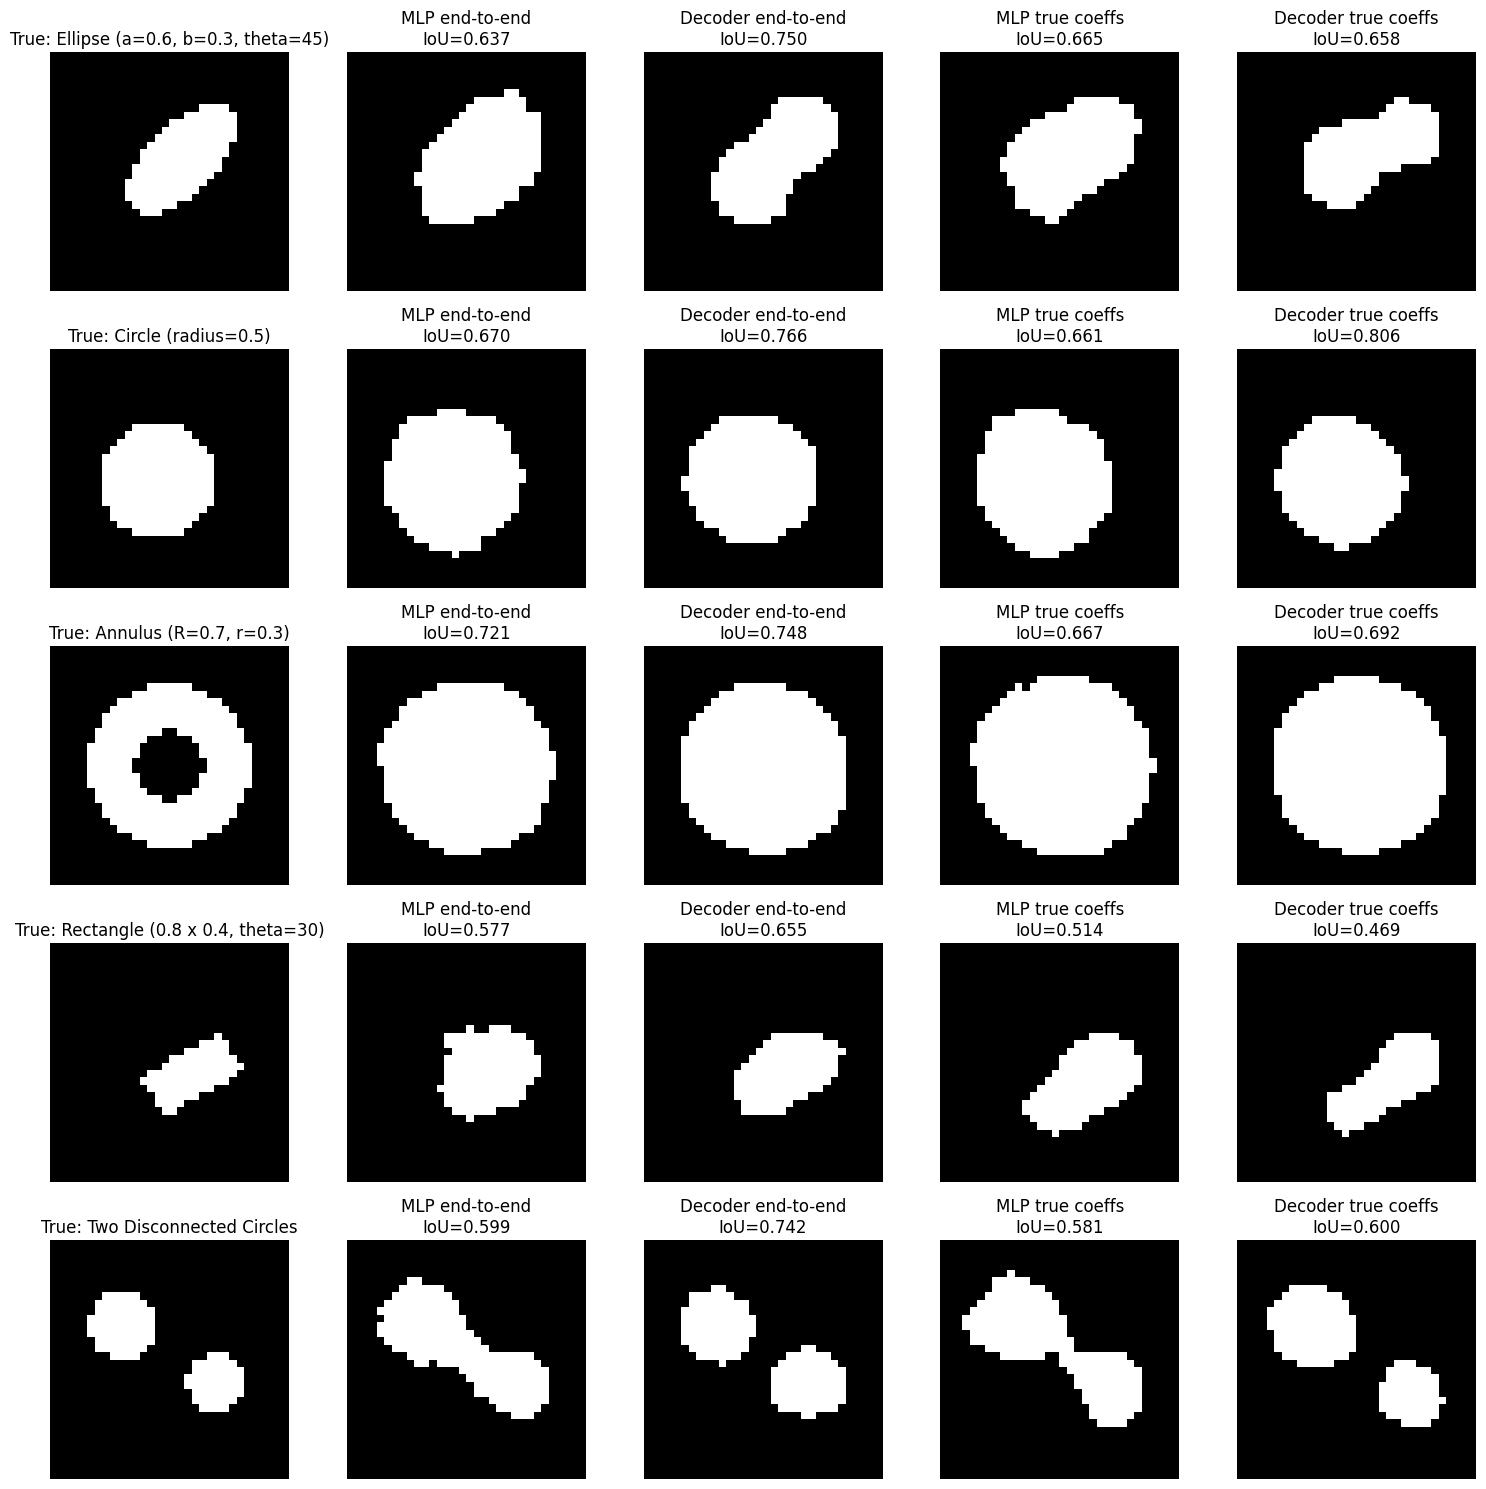

In [12]:
mlp_run = stage2_runs['mlp_edges_rectangle']
decoder_run = stage2_runs['decoder_edges_rectangle']
mlp_fixed_binary_masks = (sigmoid(mlp_run['predicted_fixed_logits']) >= run_config.threshold).astype(np.float32)
decoder_fixed_binary_masks = (sigmoid(decoder_run['predicted_fixed_logits']) >= run_config.threshold).astype(np.float32)
mlp_true_coeff_binary_masks = (sigmoid(mlp_run['true_coefficient_fixed_logits']) >= run_config.threshold).astype(np.float32)
decoder_true_coeff_binary_masks = (sigmoid(decoder_run['true_coefficient_fixed_logits']) >= run_config.threshold).astype(np.float32)
mlp_fixed_ious = compute_sample_ious(dataset.fixed.masks, mlp_run['predicted_fixed_logits'], run_config.threshold)
decoder_fixed_ious = compute_sample_ious(dataset.fixed.masks, decoder_run['predicted_fixed_logits'], run_config.threshold)
mlp_true_coeff_ious = compute_sample_ious(dataset.fixed.masks, mlp_run['true_coefficient_fixed_logits'], run_config.threshold)
decoder_true_coeff_ious = compute_sample_ious(dataset.fixed.masks, decoder_run['true_coefficient_fixed_logits'], run_config.threshold)
fig, axes = plt.subplots(len(dataset.fixed.names), 5, figsize=(15, 3 * len(dataset.fixed.names)))
for row_index, shape_name in enumerate(dataset.fixed.names):
    axes[row_index, 0].imshow(dataset.fixed.masks[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 0].set_title(f'True: {shape_name}')
    axes[row_index, 0].axis('off')

    axes[row_index, 1].imshow(mlp_fixed_binary_masks[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 1].set_title(f'MLP end-to-end\nIoU={mlp_fixed_ious[row_index]:.3f}')
    axes[row_index, 1].axis('off')

    axes[row_index, 2].imshow(decoder_fixed_binary_masks[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 2].set_title(f'Decoder end-to-end\nIoU={decoder_fixed_ious[row_index]:.3f}')
    axes[row_index, 2].axis('off')

    axes[row_index, 3].imshow(mlp_true_coeff_binary_masks[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 3].set_title(f'MLP true coeffs\nIoU={mlp_true_coeff_ious[row_index]:.3f}')
    axes[row_index, 3].axis('off')

    axes[row_index, 4].imshow(decoder_true_coeff_binary_masks[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 4].set_title(f'Decoder true coeffs\nIoU={decoder_true_coeff_ious[row_index]:.3f}')
    axes[row_index, 4].axis('off')
plt.tight_layout()
plt.show()

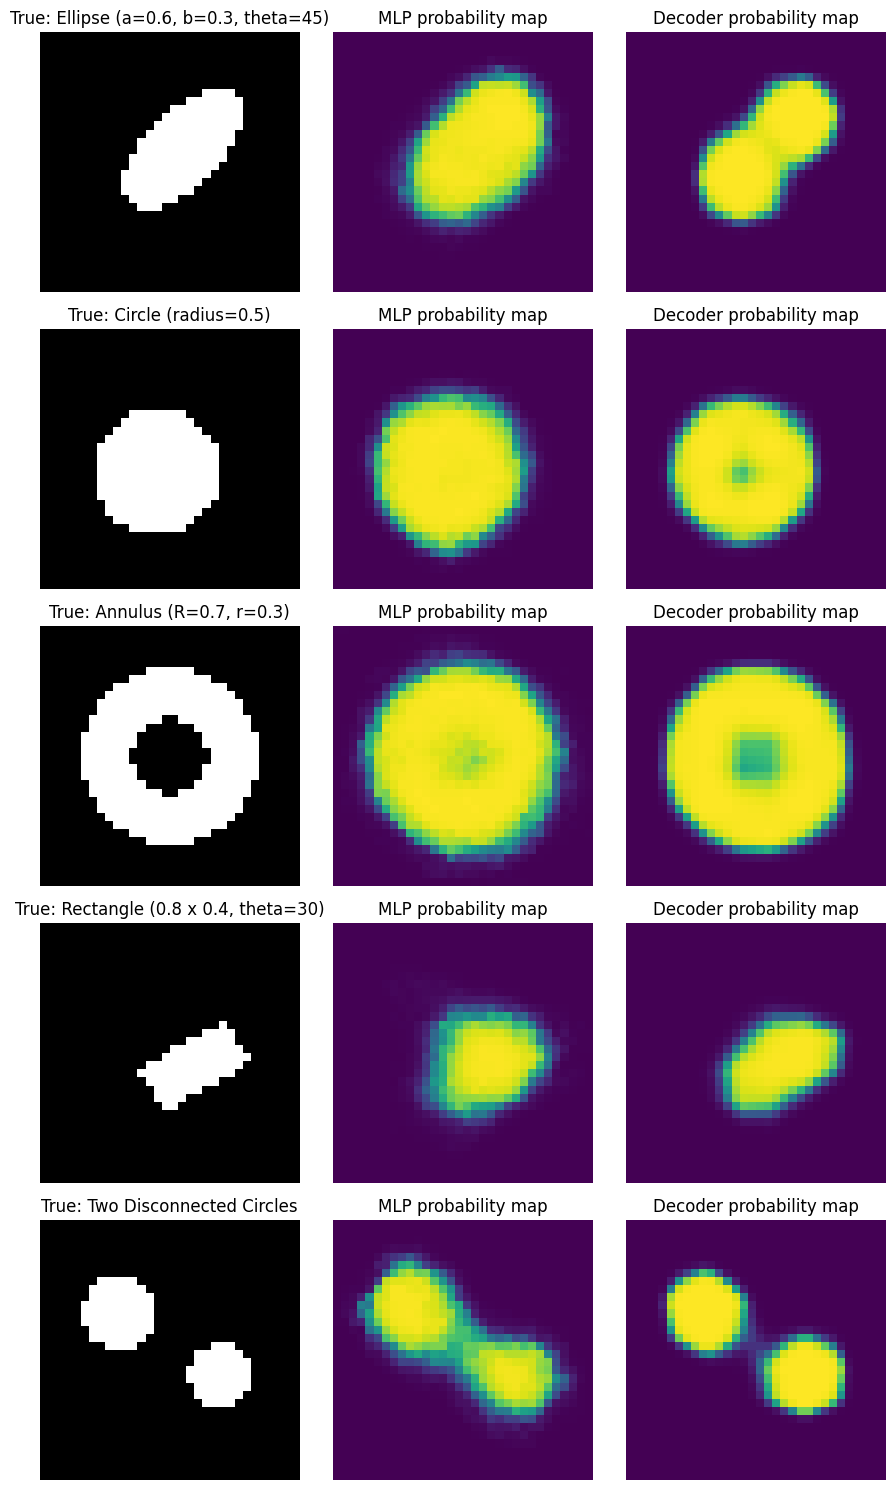

In [13]:
mlp_fixed_probabilities = sigmoid(mlp_run['predicted_fixed_logits'])
decoder_fixed_probabilities = sigmoid(decoder_run['predicted_fixed_logits'])
fig, axes = plt.subplots(len(dataset.fixed.names), 3, figsize=(9, 3 * len(dataset.fixed.names)))
for row_index, shape_name in enumerate(dataset.fixed.names):
    axes[row_index, 0].imshow(dataset.fixed.masks[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 0].set_title(f'True: {shape_name}')
    axes[row_index, 0].axis('off')

    axes[row_index, 1].imshow(mlp_fixed_probabilities[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='viridis', origin='lower', vmin=0.0, vmax=1.0)
    axes[row_index, 1].set_title('MLP probability map')
    axes[row_index, 1].axis('off')

    axes[row_index, 2].imshow(decoder_fixed_probabilities[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='viridis', origin='lower', vmin=0.0, vmax=1.0)
    axes[row_index, 2].set_title('Decoder probability map')
    axes[row_index, 2].axis('off')
plt.tight_layout()
plt.show()

## Reconstruction Comparisons

Use these views to judge whether a failure comes from Stage 1 coefficient prediction, Stage 2 mask modeling, or thresholding.

Best test IoUs: [0.95454545 0.93247588 0.92475728]
Worst test IoUs: [0. 0. 0.]


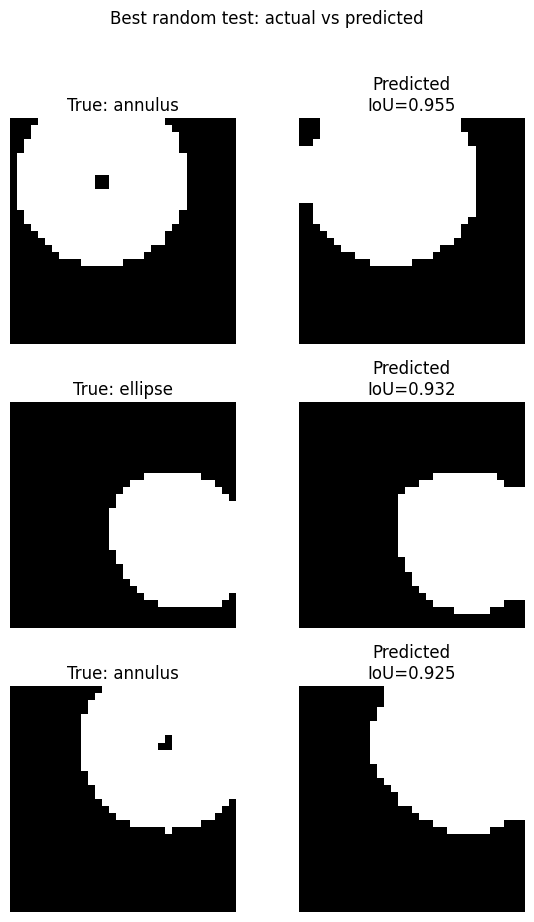

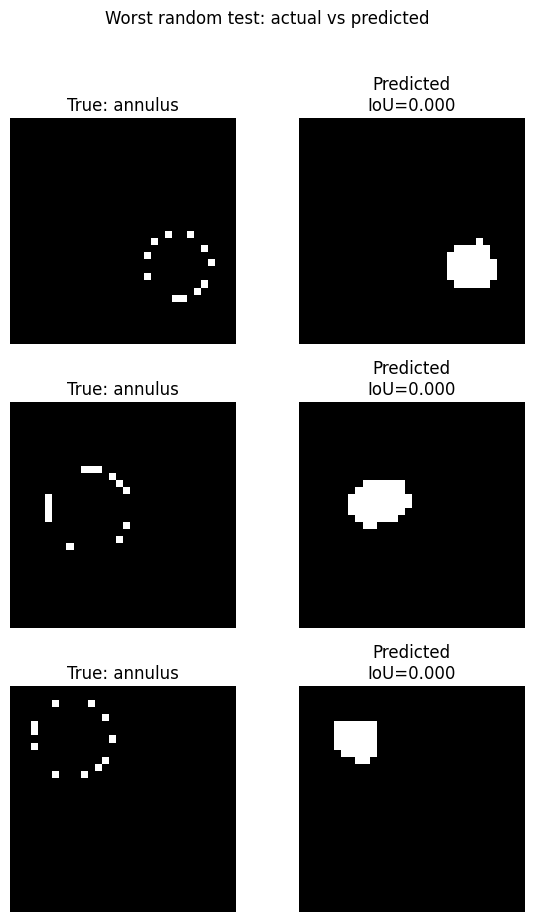

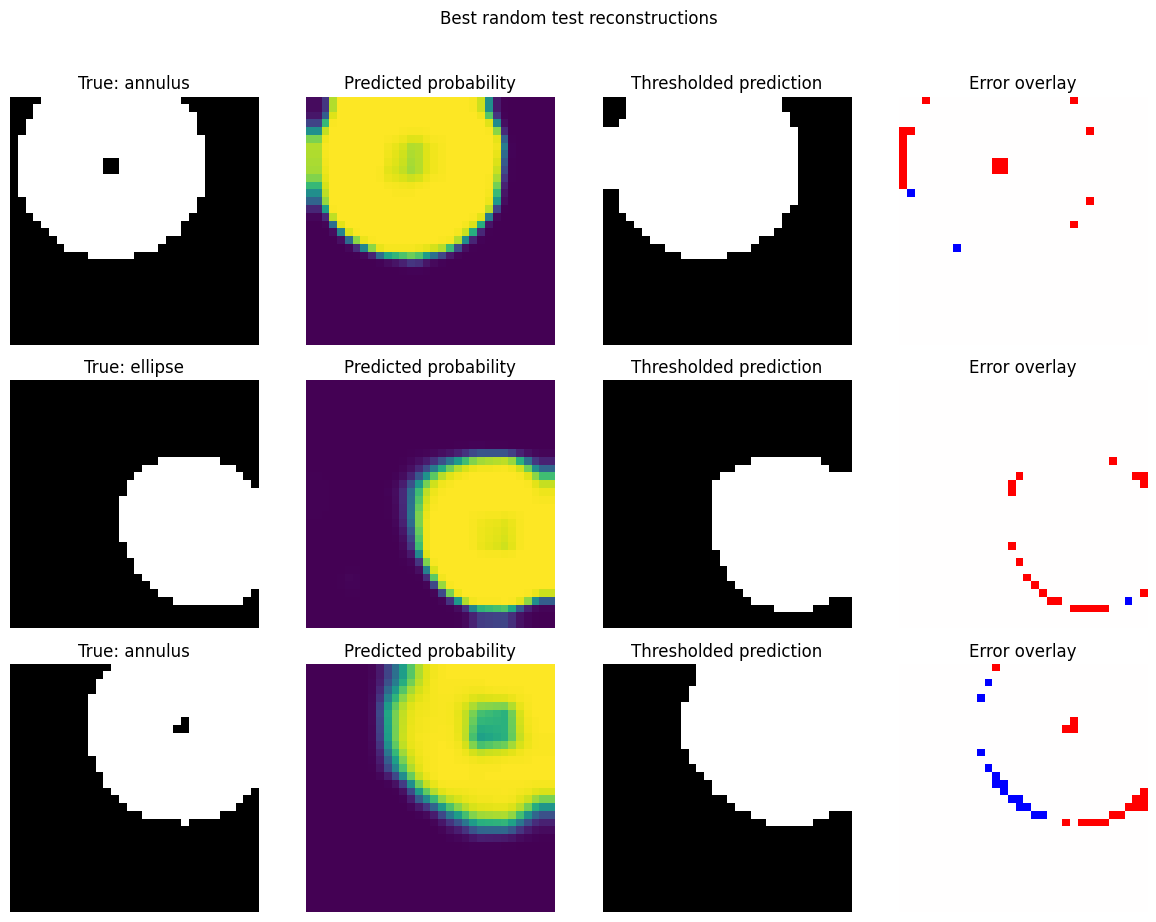

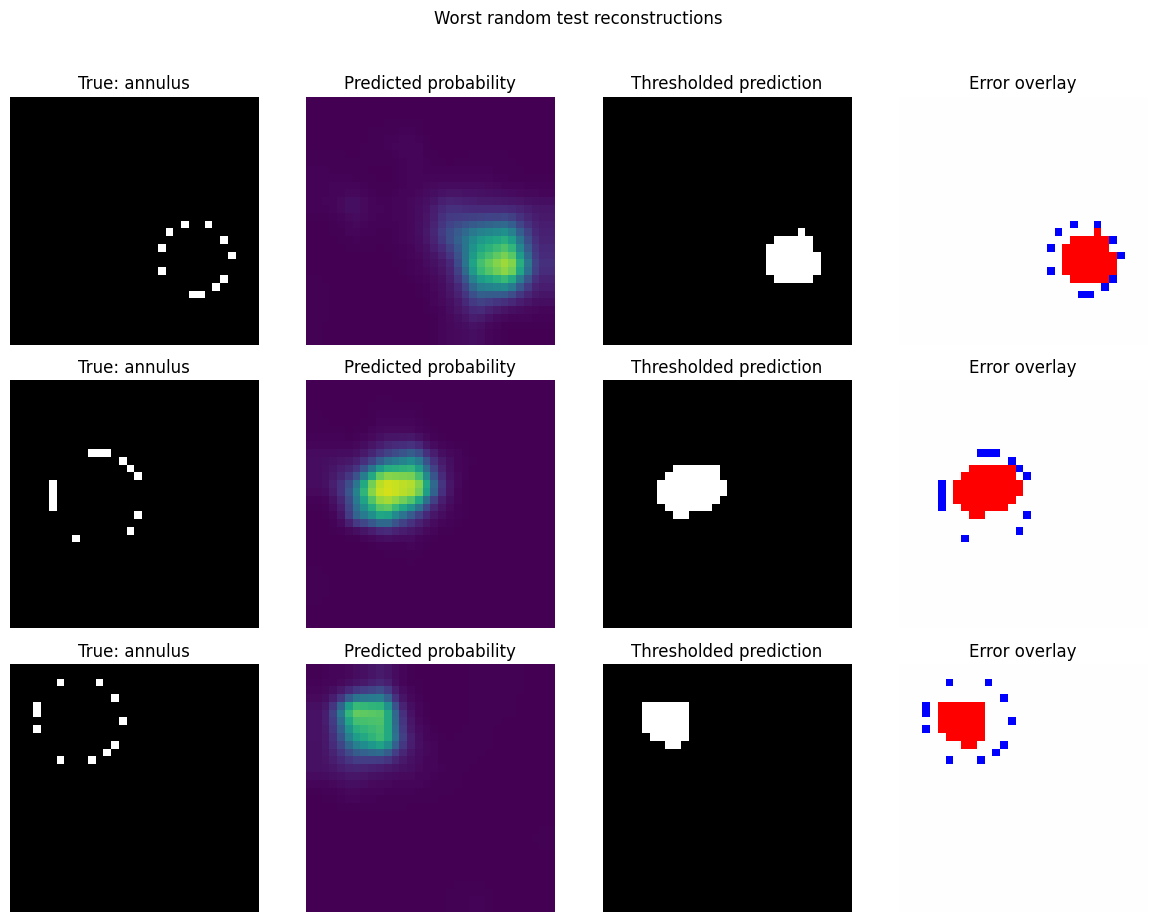

In [14]:
test_ious = compute_sample_ious(dataset.test.masks, predicted_test_logits, run_config.threshold)

best_test_indices = np.argsort(test_ious)[-3:][::-1]
worst_test_indices = np.argsort(test_ious)[:3]
print('Best test IoUs:', test_ious[best_test_indices])
print('Worst test IoUs:', test_ious[worst_test_indices])

show_simple_mask_pairs(
    dataset.test.masks,
    (sigmoid(predicted_test_logits) >= run_config.threshold).astype(np.float32),
    dataset.test.names,
    run_config.grid_size,
    best_test_indices,
    'Best random test: actual vs predicted',
    score_values=test_ious,
)
show_simple_mask_pairs(
    dataset.test.masks,
    (sigmoid(predicted_test_logits) >= run_config.threshold).astype(np.float32),
    dataset.test.names,
    run_config.grid_size,
    worst_test_indices,
    'Worst random test: actual vs predicted',
    score_values=test_ious,
)

show_reconstruction_rows(dataset.test.masks, predicted_test_logits, dataset.test.names, run_config.grid_size, run_config.threshold, best_test_indices, 'Best random test reconstructions')
show_reconstruction_rows(dataset.test.masks, predicted_test_logits, dataset.test.names, run_config.grid_size, run_config.threshold, worst_test_indices, 'Worst random test reconstructions')

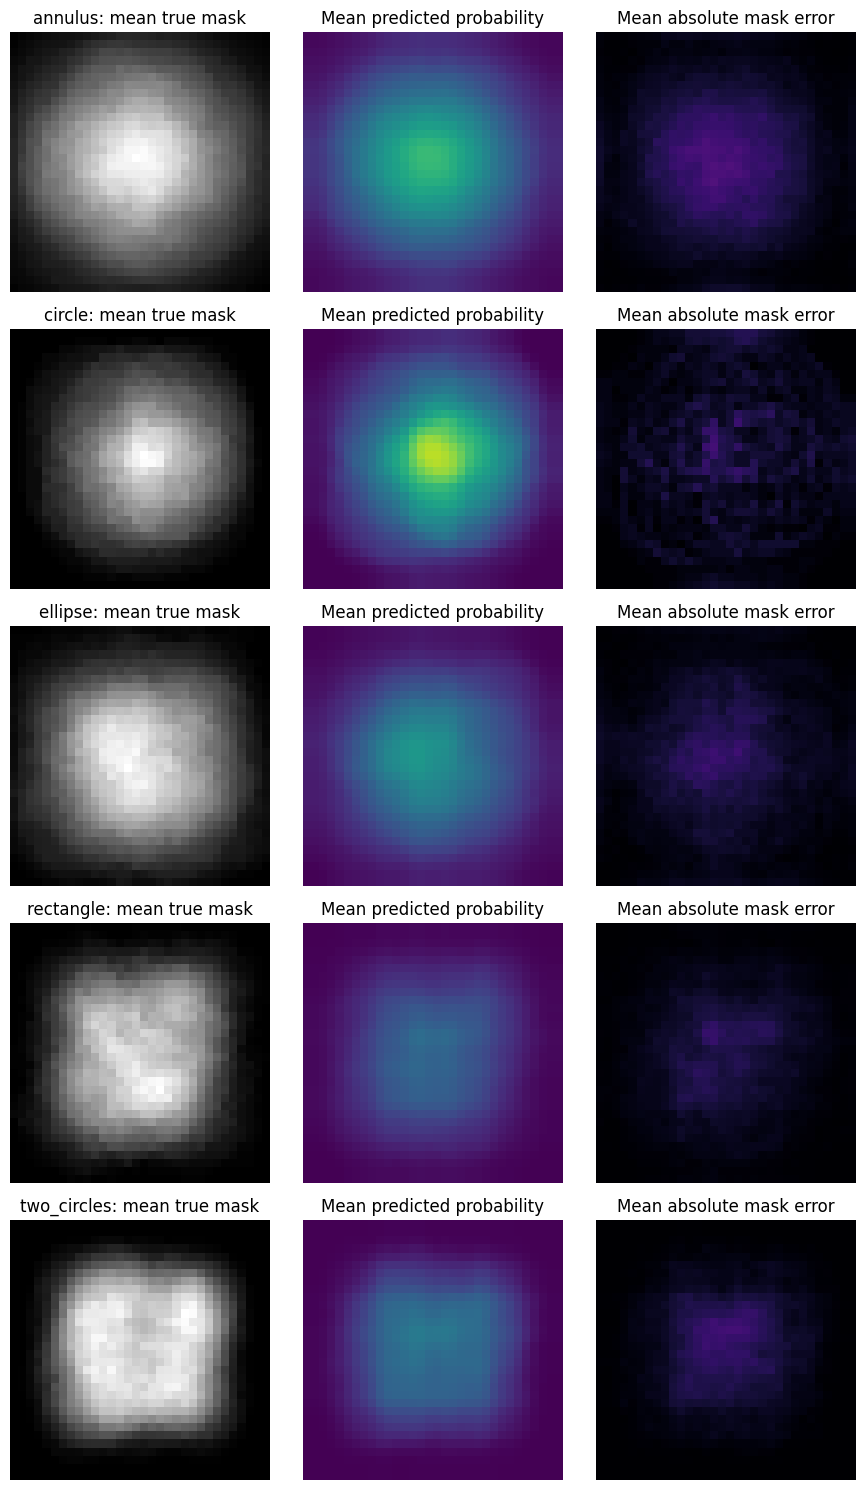

In [15]:
show_average_maps_by_shape_type(dataset.test.shape_types, dataset.test.masks, predicted_test_logits, run_config.grid_size, run_config.threshold)

## Threshold Sweep

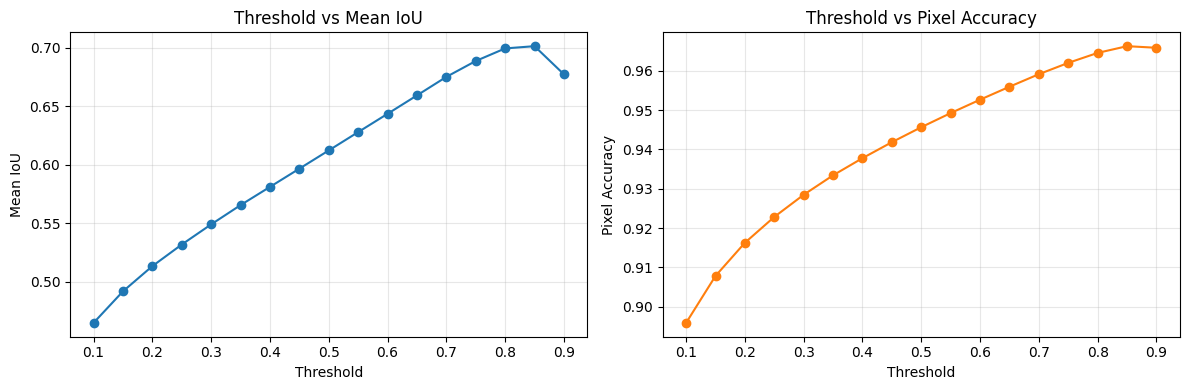

,threshold,mean_iou,pixel_accuracy
0,0.10,0.464928,0.895869
1,0.15,0.491860,0.907817
2,0.20,0.513413,0.916260
3,0.25,0.531859,0.922839
4,0.30,0.549080,0.928479
5,0.35,0.565539,0.933431
6,0.40,0.581110,0.937794
7,0.45,0.596671,0.941856
8,0.50,0.612260,0.945673
9,0.55,0.627922,0.949264


In [16]:
thresholds = np.linspace(0.1, 0.9, 17)
threshold_sweep = plot_threshold_sweep(dataset.test.masks, predicted_test_logits, thresholds)
threshold_sweep

## Failure Analysis Table

In [17]:
test_coefficient_errors = np.abs(predicted_test_coefficients - dataset.test.coefficients).mean(axis=1)
failure_table = pd.DataFrame({
    'name': dataset.test.names,
    'shape_type': dataset.test.shape_types,
    'stage1_mean_abs_coeff_error': test_coefficient_errors,
    'stage2_iou': test_ious,
    'true_mask_area': dataset.test.masks.sum(axis=1),
    'predicted_mask_area': (sigmoid(predicted_test_logits) >= run_config.threshold).astype(np.float32).sum(axis=1),
})
failure_table.sort_values('stage2_iou').head(10)

,name,shape_type,stage1_mean_abs_coeff_error,stage2_iou,true_mask_area,predicted_mask_area
1510,annulus,annulus,0.000500,0.0,11.0,38.0
521,annulus,annulus,0.000531,0.0,13.0,47.0
1845,annulus,annulus,0.000701,0.0,11.0,31.0
1591,annulus,annulus,0.001101,0.0,37.0,67.0
1472,annulus,annulus,0.000572,0.0,3.0,0.0
1552,annulus,annulus,0.000554,0.0,5.0,0.0
1890,annulus,annulus,0.001289,0.0,25.0,63.0
1131,annulus,annulus,0.000656,0.0,4.0,2.0
1327,annulus,annulus,0.000628,0.0,20.0,42.0
207,annulus,annulus,0.000467,0.0,58.0,80.0


## Compact Summary Table

In [18]:
summary_table = stage2_comparison_table.copy()
summary_table.insert(0, 'N', run_config.N)
summary_table.insert(1, 'condition_number', dataset.matrix_condition_number)
summary_table.insert(2, 'stage1_test_mse', stage1_test_metrics['mse'])
summary_table.insert(3, 'stage1_fixed_mse', stage1_fixed_metrics['mse'])
summary_table['stage1_parameters'] = count_parameters(stage1_model)
summary_table['stage1_train_epochs_recorded'] = len(stage1_result.history['train_loss'])
summary_table = summary_table[[
    'N',
    'label',
    'model_type',
    'edge_weight_mode',
    'loss_type',
    'condition_number',
    'stage1_test_mse',
    'stage1_fixed_mse',
    'stage2_validation_iou',
    'stage2_test_iou',
    'stage2_fixed_iou',
    'stage2_fixed_iou_true_coeffs',
    'stage1_parameters',
    'stage2_parameters',
    'stage1_train_epochs_recorded',
    'stage2_train_epochs_recorded',
]]
summary_table

,N,label,model_type,edge_weight_mode,loss_type,condition_number,stage1_test_mse,stage1_fixed_mse,stage2_validation_iou,stage2_test_iou,stage2_fixed_iou,stage2_fixed_iou_true_coeffs,stage1_parameters,stage2_parameters,stage1_train_epochs_recorded,stage2_train_epochs_recorded
0,15,decoder_edges_rectangle,conv_decoder,all,bce,1.0,0.000013,0.000006,0.620297,0.612260,0.732215,0.644906,74272,3711841,6,95
1,15,mlp_edges_rectangle,mlp,rectangle,bce,1.0,0.000013,0.000006,0.561322,0.554618,0.640931,0.617559,74272,4739584,6,43


## Optional Full Pipeline Smoke Test

Uncomment this cell if you want to run the real reusable entry point directly and save artifacts.

In [ ]:
from pipeline import run_two_stage_once
# full_summary = run_two_stage_once(run_config)
# full_summary['metrics']

: 